# NUTS-MCMC analysis of a quartz sample

In [1]:
import os
import os
# Set these FIRST before any other imports
os.environ["JAX_ENABLE_X64"] = "1"

In [2]:
import multiprocessing as mp
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

import refnx
from refnx.analysis import Objective, Parameter, CurveFitter, process_chain
from refnx.dataset import Data1D
from refnx.reflect import ReflectModel, SLD
from refnx.reflect.extra import compile_objective, compile_model, to_pymc_model

import jax
from jax import config

config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", message="Numba will use object mode", category=UserWarning)

In [3]:
air = SLD(0, name="air")
quartz = SLD(5, name="quartz")
sio2 = SLD(4.2, name="SiO2")
si = SLD(2.07, name="Si")

# s = air | quartz(1500, 5.0) | sio2(10, 5) | si(0, 5.0)
s = air | quartz(1500, 5.0) | si(0, 5.0)


quartz.real.setp(vary=True, bounds=(0, 5.0))
sio2.real.setp(vary=True, bounds=(0, 5.0))
# si.real.setp(vary=True, bounds=(0, 5.0))

s[1].thick.setp(vary=True, bounds=(1400.0, 1500.0))
s[1].rough.setp(vary=True, bounds=(2.0, 20.0))

# s[2].thick.setp(vary=True, bounds=(0.0, 50.0))
# s[2].rough.setp(vary=True, bounds=(2.0, 20.0))

s[-1].rough.setp(vary=True, bounds=(2.0, 20.0))

bkg = Parameter(1e-7, name="bkg", vary=True, bounds=(1e-20, 1))
scale = Parameter(1.0, name="scale", vary=True, bounds=(0.9, 1.5))

model = ReflectModel(s, bkg=bkg, scale=scale)

data = np.loadtxt("../refnx/reflect/tests/.Quartz_data.txt", delimiter=",")
data = data[:, 1:]
data = Data1D(data.T, name="data")

# q-resolution column is a standard deviation
data.x_err *= 2.3548

objective = Objective(model, data)

In [4]:
fitter = CurveFitter(objective)
fitter.fit("differential_evolution");

-5266.308670011519: : 53it [00:02, 19.95it/s]


In [5]:
model = to_pymc_model(objective)

In [6]:
with model:
    idata = pm.sample(mp_ctx=mp.get_context("forkserver"))
    # idata = pm.sample(chains=4, cores=4, mp_ctx=mp.get_context("forkserver"))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p0, p1, p2, p3, p4, p5]


Output()

/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/andrew/.conda/envs/dev3/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run _LogLikeValueGradOp's perform meth

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 62 seconds.


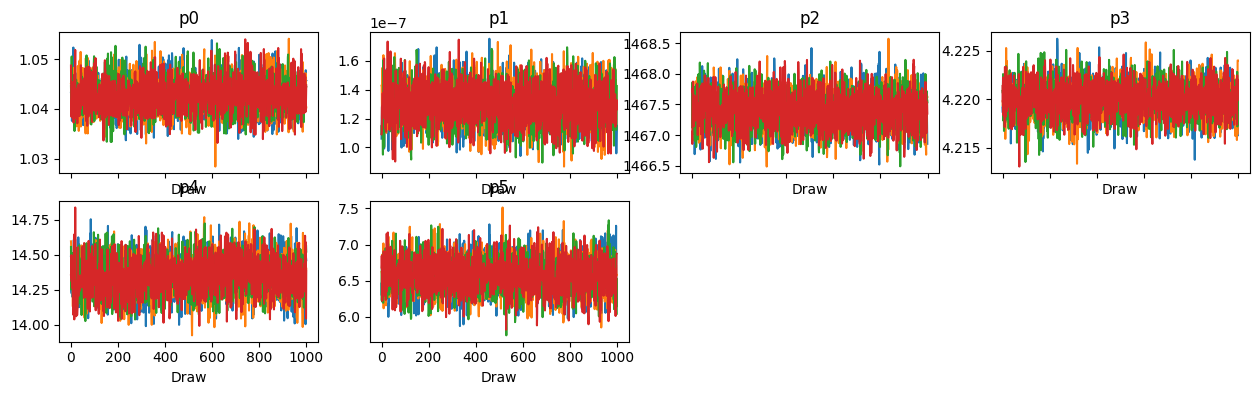

In [7]:
az.plot_trace(idata);

In [8]:
posterior_dataset = idata.posterior

summary = az.summary(idata)
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
p0,1.0428,0.00332,1,1,4099,3045,1.00,5.2e-05,3.7e-05
p1,1.298e-07,1.37e-08,1.1e-07,1.5e-07,3422,2941,1.00,2.3e-10,1.6e-10
p2,1467.4,0.288,1500,1500,4257,3524,1.00,0.0044,0.0031
p3,4.21994,0.0017,4.2,4.2,3895,3145,1.00,2.7e-05,2e-05
p4,14.351,0.13,14,15,3286,2934,1.00,0.0023,0.0015
p5,6.568,0.239,6.2,6.9,3235,3073,1.00,0.0042,0.0029


In [9]:
# bring the pymc traces back into the Objective.
npars = len(objective.varying_parameters())
total_chain = [posterior_dataset[f'p{i}'].to_numpy() for i in range(npars)]
tc = np.r_[total_chain]
process_chain(objective, np.swapaxes(tc, 0, 2));

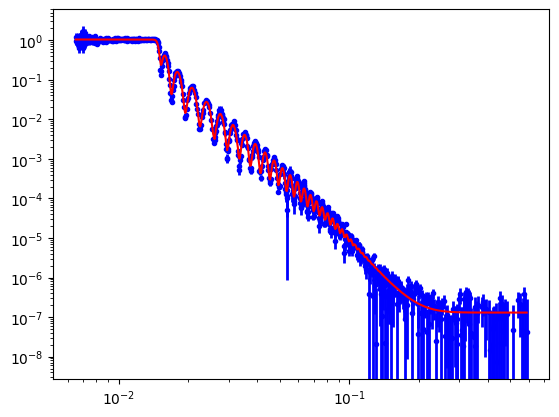

In [10]:
objective.plot()#samples=1000);
plt.xscale("log")
plt.yscale("log")
# plt.xlim(0.01, 0.04);
# plt.ylim(0.001, 1.2);

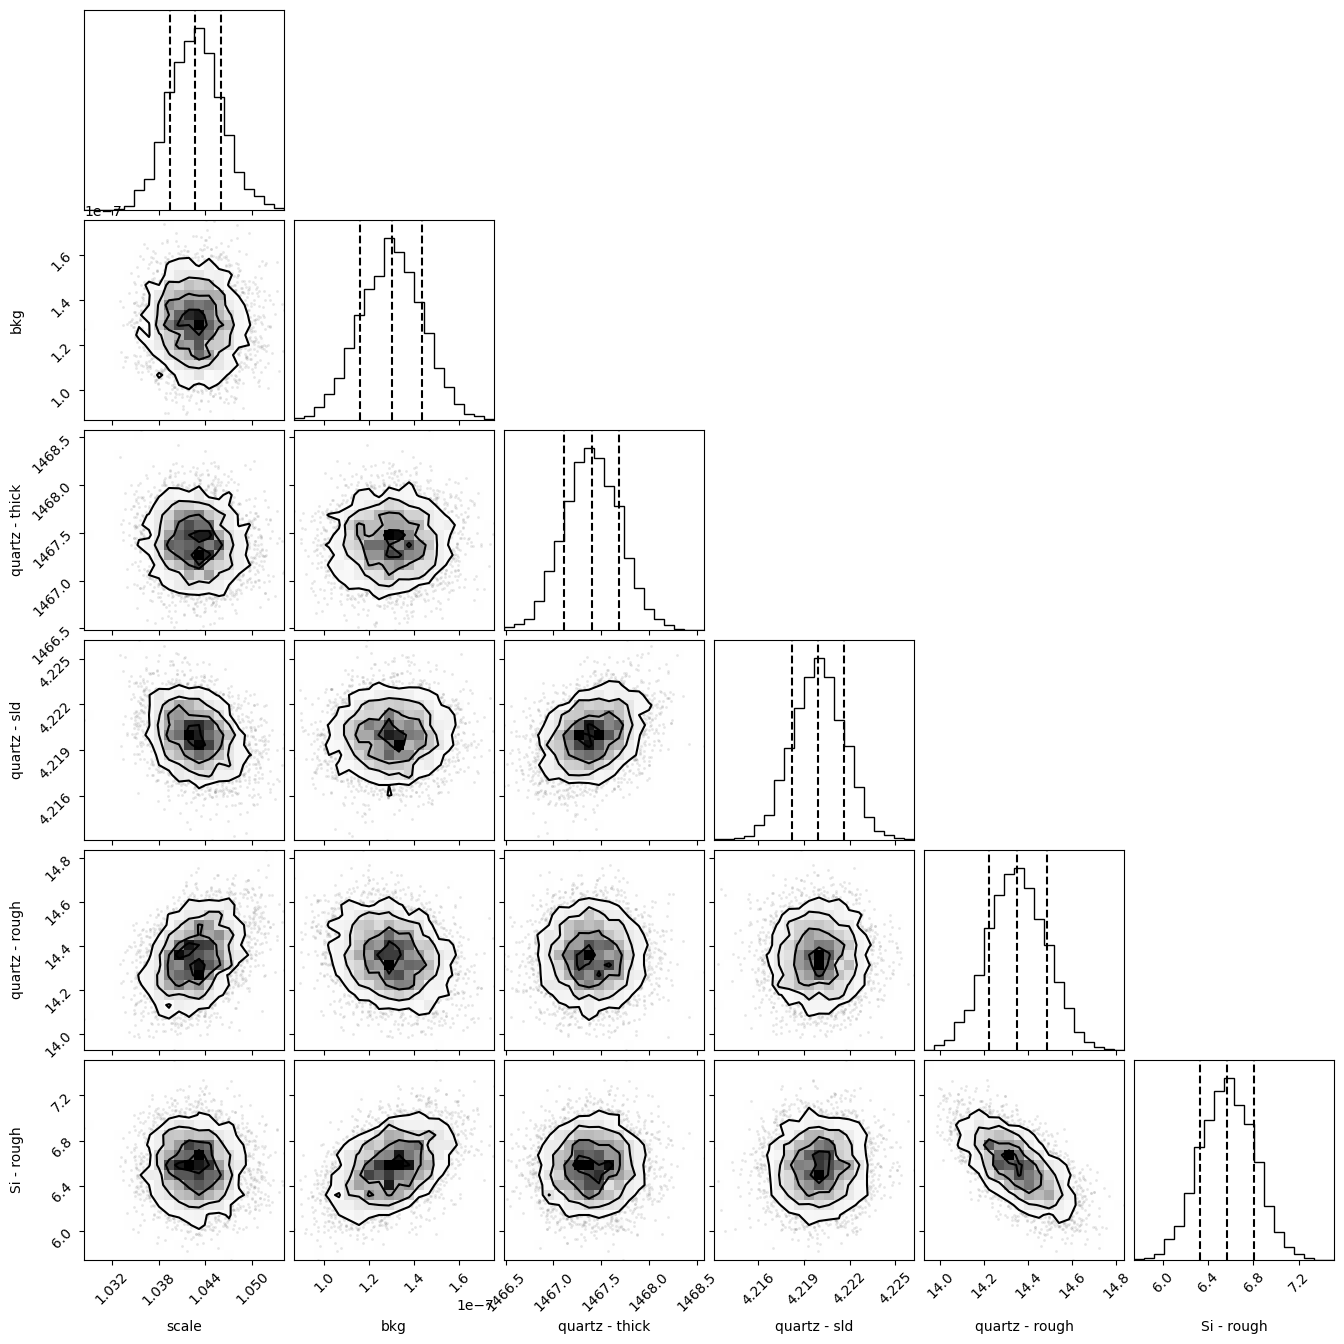

In [11]:
objective.corner();

In [12]:
print(objective.varying_parameters())

________________________________________________________________________________
Parameters:      None      
<Parameter:    'scale'    , value=1.04272 +/- 0.00328, bounds=[0.9, 1.5]>
<Parameter:     'bkg'     , value=1.30169e-07 +/- 1.38e-08, bounds=[1e-20, 1.0]>
<Parameter:'quartz - thick', value=1467.4 +/- 0.288, bounds=[1400.0, 1500.0]>
<Parameter:'quartz - sld' , value=4.21994 +/- 0.00172, bounds=[0.0, 5.0]>
<Parameter:'quartz - rough', value=14.3488 +/- 0.133, bounds=[2.0, 20.0]>
<Parameter: 'Si - rough'  , value=6.56532 +/- 0.241, bounds=[2.0, 20.0]>


In [13]:
# This process furnishes an object that can calculate logl, grad(logl) for an Objective.
obj = compile_objective(objective)
value_and_grad = obj.value_and_grad

value, grad = value_and_grad(np.array(objective.varying_parameters()))
print(f"log-likelihood = {value}\ngrad(log-likelihood) = {grad}")

log-likelihood = 5279.853064162691
grad(log-likelihood) = [ 3.13212538e+00 -6.15625947e+05 -9.28379605e-02  2.22700507e+01
  1.30129465e-01  9.56766237e-02]
